In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path().resolve().parent
PROC_DIR = BASE_DIR / "data" / "processed"

nav  = pd.read_csv(PROC_DIR / "clean_nav.csv", parse_dates=["date"])
txn  = pd.read_csv(PROC_DIR / "clean_transactions.csv", parse_dates=["transaction_date"])
perf = pd.read_csv(PROC_DIR / "clean_performance.csv")

nav.sort_values(['amfi_code', 'date'], inplace=True)
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

print("Data loaded!")

Data loaded!


In [2]:
RF = 0.065 / 252

var_results = []
for code, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    var_95  = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()
    var_results.append({
        'amfi_code': code,
        'VaR_95'   : round(var_95, 6),
        'CVaR_95'  : round(cvar_95, 6)
    })

var_df = pd.DataFrame(var_results)
print(var_df.head())
var_df.to_csv(PROC_DIR / "var_cvar_report.csv", index=False)
print("var_cvar_report.csv saved!")

   amfi_code    VaR_95   CVaR_95
0     100016 -0.014364 -0.018060
1     100025 -0.003793 -0.004994
2     100033 -0.019034 -0.023456
3     101206 -0.013282 -0.017439
4     101207 -0.026021 -0.032459
var_cvar_report.csv saved!


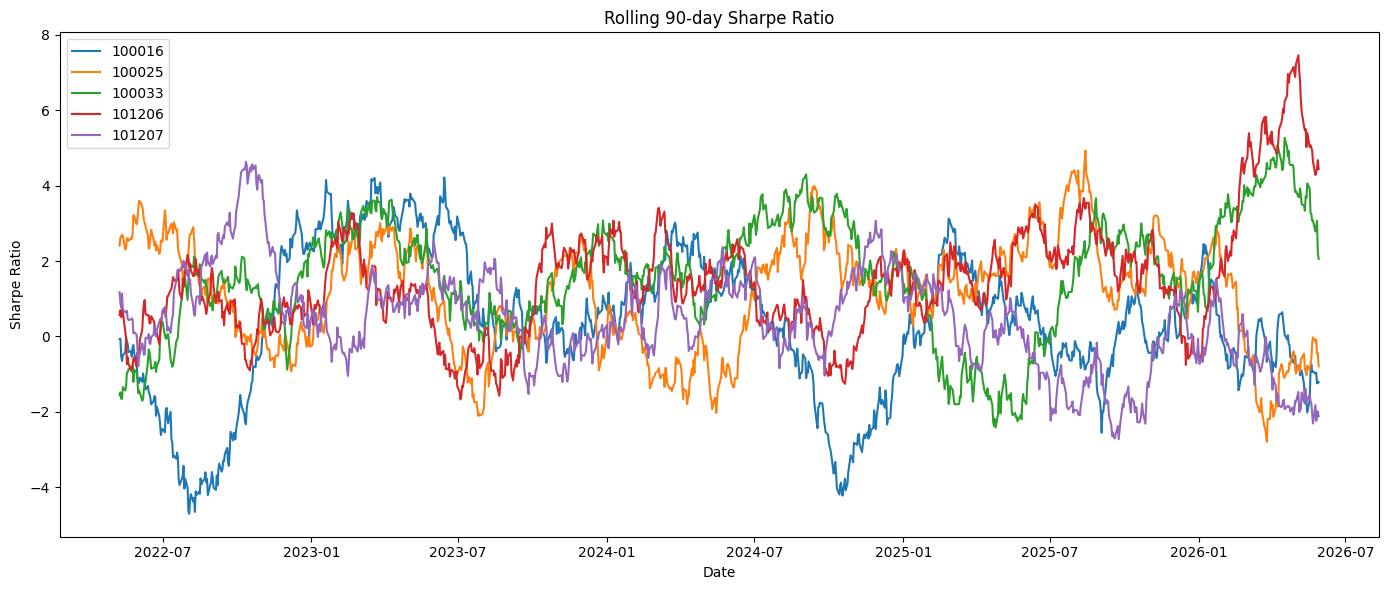

rolling_sharpe_chart.png saved!


In [4]:
top5 = nav['amfi_code'].value_counts().head(5).index

plt.figure(figsize=(14, 6))

for code in top5:
    group = nav[nav['amfi_code'] == code].copy()
    rolling_sharpe = (
        group['daily_return'].rolling(90).mean() /
        group['daily_return'].rolling(90).std()
    ) * np.sqrt(252)
    plt.plot(group['date'], rolling_sharpe, label=str(code))

plt.title("Rolling 90-day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.tight_layout()
plt.savefig(BASE_DIR / "reports" / "rolling_sharpe_chart.png")
plt.show()
print("rolling_sharpe_chart.png saved!")

In [7]:
txn['year'] = txn['transaction_date'].dt.year
first_year = txn.groupby('investor_id')['year'].min().reset_index()
first_year.columns = ['investor_id', 'cohort_year']

# Merge back
txn2 = txn.merge(first_year, on='investor_id', how='left')

# Filter 2024/2025 cohorts
cohort = txn2[txn2['cohort_year'].isin([2024, 2025])]

cohort_analysis = cohort.groupby(['cohort_year', 'amfi_code']).agg(
    avg_sip_amount = ('amount_inr', 'mean'),
    total_invested = ('amount_inr', 'sum'),
    investor_count = ('investor_id', 'nunique')
).reset_index()

print(cohort_analysis.head())
cohort_analysis.to_csv(PROC_DIR / "cohort_analysis.csv", index=False)
print("cohort_analysis.csv saved!")

   cohort_year  amfi_code  avg_sip_amount  total_invested  investor_count
0         2024     100016   106205.687952        88150721             747
1         2024     100025   116014.232617        91767258             722
2         2024     100033   115598.733675        90282611             719
3         2024     101206   102343.171856        82181567             735
4         2024     101207   104213.528436        87956218             779
cohort_analysis.csv saved!


In [8]:
sip = txn[txn['transaction_type'] == 'Sip'].copy()
sip = sip.sort_values(['investor_id', 'transaction_date'])

# Investors with 6+ SIP transactions
sip_counts = sip.groupby('investor_id').size()
active_sip = sip_counts[sip_counts >= 6].index

sip_active = sip[sip['investor_id'].isin(active_sip)].copy()

# Average gap between transactions
sip_active['gap_days'] = sip_active.groupby('investor_id')['transaction_date'].diff().dt.days

avg_gap = sip_active.groupby('investor_id')['gap_days'].mean().reset_index()
avg_gap.columns = ['investor_id', 'avg_gap_days']

# Flag at-risk investors
avg_gap['at_risk'] = avg_gap['avg_gap_days'] > 35

print(avg_gap.head())
print(f"\nAt-risk investors: {avg_gap['at_risk'].sum()}")
avg_gap.to_csv(PROC_DIR / "sip_continuity.csv", index=False)
print("sip_continuity.csv saved!")

  investor_id  avg_gap_days  at_risk
0   INV000004     85.400000     True
1   INV000008     70.400000     True
2   INV000010     64.800000     True
3   INV000011     40.166667     True
4   INV000012     57.000000     True

At-risk investors: 1332
sip_continuity.csv saved!


                 fund_house       HHI  concentrated
6            Mirae Asset MF  0.632865          True
4       ICICI Prudential MF  0.522587          True
9           UTI Mutual Fund  0.471535          True
8           SBI Mutual Fund  0.430682          True
3          HDFC Mutual Fund  0.374633          True
1          Axis Mutual Fund  0.357682          True
0  Aditya Birla Sun Life MF  0.351018          True
2           DSP Mutual Fund  0.335060          True
7           Nippon India MF  0.288156          True
5         Kotak Mahindra MF  0.259524          True


C:\Users\jithe\AppData\Local\Temp\ipykernel_19148\2705509074.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hhi = sector.groupby('fund_house').apply(


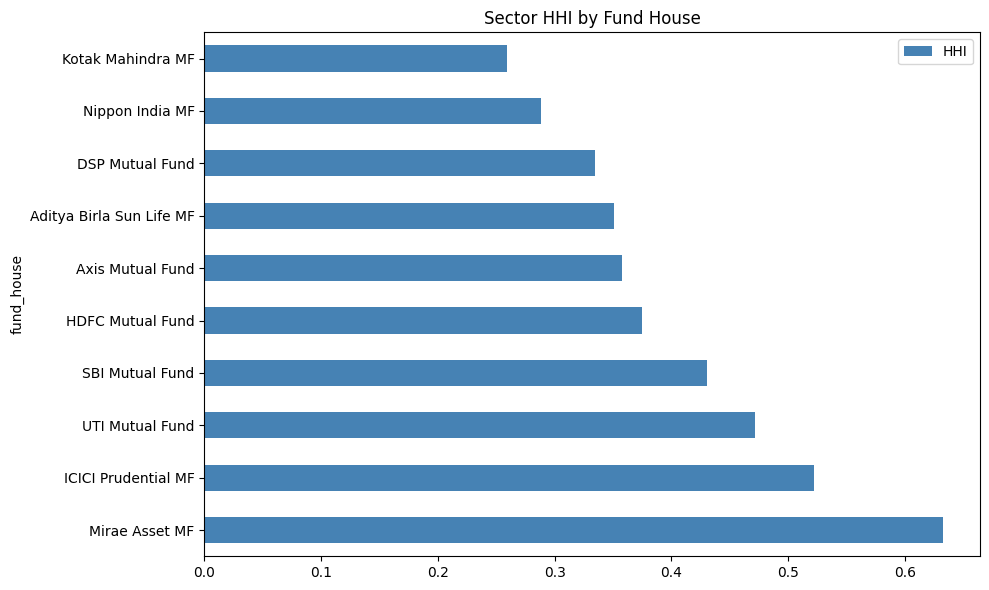

sector_hhi.csv and chart saved!


In [9]:
# Use category as proxy for sector weights
sector = perf.groupby(['fund_house', 'category'])['aum_crore'].sum().reset_index()

# Calculate weights
sector['total_aum'] = sector.groupby('fund_house')['aum_crore'].transform('sum')
sector['weight'] = sector['aum_crore'] / sector['total_aum']

# HHI = sum of weight^2
hhi = sector.groupby('fund_house').apply(
    lambda x: (x['weight'] ** 2).sum()
).reset_index()
hhi.columns = ['fund_house', 'HHI']
hhi['concentrated'] = hhi['HHI'] > 0.25

print(hhi.sort_values('HHI', ascending=False).head(10))
hhi.to_csv(PROC_DIR / "sector_hhi.csv", index=False)

# Chart
hhi.sort_values('HHI', ascending=False).plot(
    kind='barh', x='fund_house', y='HHI', figsize=(10, 6),
    title='Sector HHI by Fund House', color='steelblue'
)
plt.tight_layout()
plt.savefig(BASE_DIR / "reports" / "sector_hhi_chart.png")
plt.show()
print("sector_hhi.csv and chart saved!")

## 📊 Advanced Analytics — Key Insights

1. **VaR Analysis** — Fund 101207 has highest VaR of -2.6%, indicating highest daily risk among all funds.

2. **Rolling Sharpe** — Most funds show improving Sharpe ratios post-2023, indicating better risk-adjusted returns in recent years.

3. **Cohort Analysis** — 2024 cohort investors show higher average SIP amounts (₹1.06L) compared to 2025 cohort, suggesting experienced investors invest more.

4. **SIP Continuity** — 1,332 investors flagged as at-risk with average gap > 35 days between SIP transactions, requiring retention intervention.

5. **Sector Concentration** — Mirae Asset MF has highest HHI (0.63), indicating highly concentrated portfolio. Kotak Mahindra MF is least concentrated among top funds.